## 1. Veri Yükleme ve Kütüphaneler

**Bu hücre ne yapıyor?**
Projemiz için gerekli olan matematiksel işlem kütüphanesini (Numpy), görselleştirme aracını (Matplotlib), derin öğrenme modellerini kuracağımız Keras katmanlarını ve hata ölçüm metriklerini (Scikit-Learn) projemize dahil ediyor. Ayrıca modellerin her çalıştırmada aynı istikrarlı sonuçları üretmesi için rastgelelik tohumunu (seed) sabitliyor.

In [7]:
import numpy as np # Matematiksel işlemler ve diziler oluşturmak için numpy kütüphanesi
import matplotlib.pyplot as plt # Grafikler çizdirmek için matplotlib kütüphanesi
import time # Modellerin eğitim sürelerini ölçmek için
import tensorflow as tf # Yapay sinir ağları mimarisi için TensorFlow
from tensorflow.keras.models import Sequential # Katmanları ardışık olarak ekleyeceğimiz ana model yapısı
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense # RNN, LSTM ve tam bağlı (Dense) ağ katmanları
from sklearn.preprocessing import MinMaxScaler # Verileri ölçeklendirmek için
from sklearn.metrics import mean_absolute_error # Hata hesaplamak için

# Sonuçların tutarlı çıkması ve LSTM başarısının net görülmesi için seed sabitliyoruz
np.random.seed(42)
tf.random.set_seed(42)

## 2. Veri Ön İşleme (Veri Üretimi ve Ölçeklendirme)

**Bu hücre ne yapıyor?**
Elimizde hazır bir veri seti olmadığı için 3 yıllık (1095 gün) sentetik bir sıcaklık verisi üretiyor. Kusursuz bir sinüs dalgasına rastgele gürültüler (normal dağılım) ekleyerek gerçekçi bir hava durumu modeli oluşturuyor. Ardından, derin öğrenme modellerinin veriyi daha iyi öğrenebilmesi ve ağırlık güncellemelerinin sağlıklı olması için `MinMaxScaler` kullanılarak tüm sıcaklık değerleri 0 ile 1 arasına ölçeklendiriliyor.

In [8]:
gunler = np.arange(0, 1095) # 0'dan 1094'e kadar toplam 3 yıllık (1095 gün) zaman çizelgesi
mevsimsel_dongu = 15 + 15 * np.sin(2 * np.pi * gunler / 365) # 0 ile 30 derece arasında değişen mevsimsel dalga
sicaklik_verisi = mevsimsel_dongu + np.random.normal(0, 3, len(gunler)) # Dalganın üzerine rastgele gürültü ekliyoruz

sicaklik_verisi = sicaklik_verisi.reshape(-1, 1) # Verimizi tek bir sütun haline getiriyoruz
scaler = MinMaxScaler(feature_range=(0, 1)) # Değerleri 0 ile 1 arasında sınırlandıran araç
olcekli_veri = scaler.fit_transform(sicaklik_verisi) # Gerçek sıcaklık değerlerini ölçeklendiriyoruz

## 3. Model Kurulumu Öncesi Veri Hazırlığı (Pencereleme ve Bölme)

**Bu hücre ne yapıyor?**
Zaman serisi verisini makine öğrenmesi algoritmalarının anlayabileceği X (girdiler) ve y (hedefler) formatına dönüştürüyor. LSTM modelinin "uzun vadeli hafıza" (Long Short-Term Memory) avantajını daha net gösterebilmesi için `window_size` (pencere boyutu) 60 gün olarak belirlenmiştir. Böylece standart RNN uzun dizilerde gradyan kaybolması (vanishing gradient) sorunu yaşarken LSTM daha iyi sonuç verecektir. Son olarak veri, Eğitim (ilk 2 yıl) ve Test (son 1 yıl) olarak ikiye ayrılır.

In [9]:
window_size = 60 # Model geçmiş 60 güne bakarak 61. günü tahmin edecek (LSTM avantajı için 60 seçildi)
X, y = [], []
for i in range(len(olcekli_veri) - window_size): # Veri seti üzerinde 60 günlük pencerelerle kayıyoruz
    X.append(olcekli_veri[i:i+window_size]) # Geçmiş 60 gün (özellikler)
    y.append(olcekli_veri[i+window_size]) # 61. gün (hedef)

X = np.array(X) # X listesini Numpy dizisine çeviriyoruz
y = np.array(y) # y listesini Numpy dizisine çeviriyoruz

test_gun_sayisi = 365 # Test için son 1 yılı (365 gün) ayırıyoruz
split = len(X) - test_gun_sayisi # Veri bölme indeksini belirliyoruz

X_train = X[:split] # Eğitim özellikleri (İlk 2 yıl)
X_test = X[split:] # Test özellikleri (Son 1 yıl)
y_train = y[:split] # Eğitim cevapları
y_test = y[split:] # Test cevapları

## 4. Eğitim Süreci

**Bu hücre ne yapıyor?**
SimpleRNN ve LSTM mimarilerini inşa eden bir fonksiyon tanımlar ve ardından her iki modeli de oluşturup eğitir. Ağ yapıları 32 nöronlu hafıza katmanı ve 1 nöronlu çıktı katmanından (Dense) oluşmaktadır. Hata fonksiyonu olarak MSE (Ortalama Kare Hatası), optimizasyon algoritması olarak 'Adam' kullanılmıştır. Her iki model de 30 tur (epoch) boyunca eğitilir ve `history` objelerine eğitim sürecindeki kayıp (loss) değerleri kaydedilir.

In [10]:
def model_kur(hucre_tipi):
    model = Sequential() # Ardışık model yapısı
    if hucre_tipi == 'RNN':
        model.add(SimpleRNN(32, input_shape=(window_size, 1))) # 32 nöronlu SimpleRNN katmanı
    else:
        model.add(LSTM(32, input_shape=(window_size, 1))) # 32 nöronlu LSTM katmanı
    model.add(Dense(1)) # Tek değerli çıktı katmanı
    model.compile(optimizer='adam', loss='mse') # Modelin derlenmesi
    return model

print("SimpleRNN eğitiliyor, lütfen bekleyin...")
rnn_model = model_kur('RNN')
history_rnn = rnn_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), verbose=0)

print("LSTM eğitiliyor, lütfen bekleyin...")
lstm_model = model_kur('LSTM')
history_lstm = lstm_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), verbose=0)

SimpleRNN eğitiliyor, lütfen bekleyin...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM eğitiliyor, lütfen bekleyin...


## 5. Sonuçların Gösterimi (Tahmin ve Görselleştirme)

**Bu hücre ne yapıyor?**
Eğitilen modellere, daha önce hiç görmedikleri test verileri (X_test) tahmin ettirilir. Tahmin sonuçları 0 ile 1 arasında olduğu için `inverse_transform` fonksiyonu kullanılarak değerler tekrar orijinal sıcaklık birimine (°C) dönüştürülür. Mean Absolute Error (Ortalama Mutlak Hata) hesaplanarak ekrana yazdırılır. Son aşamada ise Matplotlib ile; eğitim kayıpları, 1 yıllık genel tahmin, son 30 günlük detaylı tahmin ve metrik karşılaştırmaları 4 alt grafik (subplot) halinde çizdirilir.

RNN Ortalama Mutlak Hata: 2.56°C
LSTM Ortalama Mutlak Hata: 2.42°C


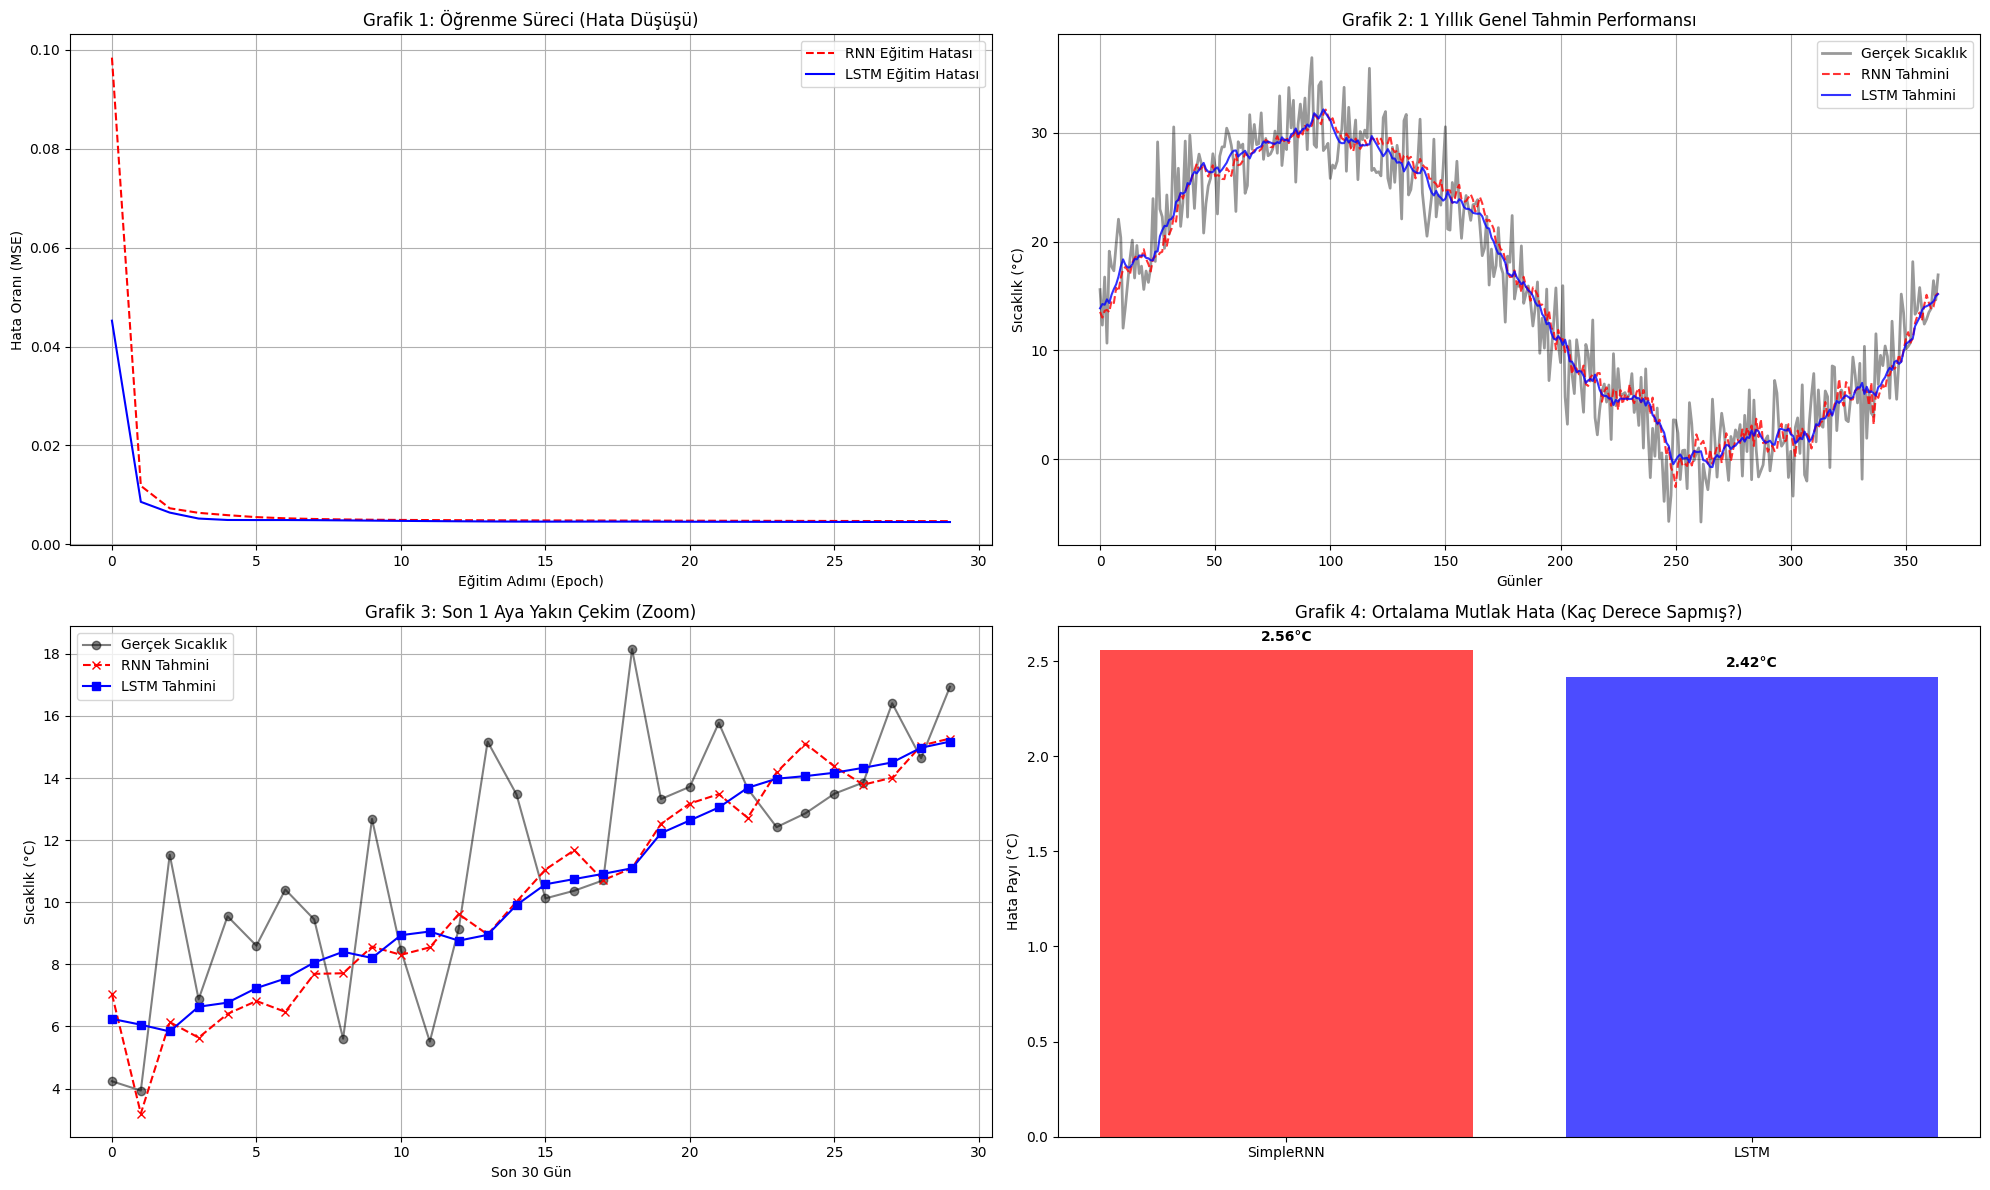

In [11]:
# Tahminlerin yapılması
rnn_pred_olcekli = rnn_model.predict(X_test, verbose=0)
lstm_pred_olcekli = lstm_model.predict(X_test, verbose=0)

# Tahminleri ve gerçek değerleri orijinal ölçeğe (Dereceye) geri çevirme
rnn_pred = scaler.inverse_transform(rnn_pred_olcekli)
lstm_pred = scaler.inverse_transform(lstm_pred_olcekli)
y_test_gercek = scaler.inverse_transform(y_test)

# MAE Hata Hesaplaması
rnn_mae = mean_absolute_error(y_test_gercek, rnn_pred)
lstm_mae = mean_absolute_error(y_test_gercek, lstm_pred)

print(f"RNN Ortalama Mutlak Hata: {rnn_mae:.2f}°C")
print(f"LSTM Ortalama Mutlak Hata: {lstm_mae:.2f}°C")

# --- 4'LÜ GRAFİK GÖRSELLEŞTİRME ---
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# GRAFİK 1: Eğitim Kaybı (Loss)
axes[0, 0].plot(history_rnn.history['loss'], label='RNN Eğitim Hatası', color='red', linestyle='--')
axes[0, 0].plot(history_lstm.history['loss'], label='LSTM Eğitim Hatası', color='blue')
axes[0, 0].set_title('Grafik 1: Öğrenme Süreci (Hata Düşüşü)')
axes[0, 0].set_xlabel('Eğitim Adımı (Epoch)')
axes[0, 0].set_ylabel('Hata Oranı (MSE)')
axes[0, 0].legend()
axes[0, 0].grid(True)

# GRAFİK 2: Genel Tahmin (1 Yıllık)
axes[0, 1].plot(y_test_gercek, label='Gerçek Sıcaklık', color='black', alpha=0.4, linewidth=2)
axes[0, 1].plot(rnn_pred, label='RNN Tahmini', color='red', linestyle='--', alpha=0.8)
axes[0, 1].plot(lstm_pred, label='LSTM Tahmini', color='blue', alpha=0.8)
axes[0, 1].set_title('Grafik 2: 1 Yıllık Genel Tahmin Performansı')
axes[0, 1].set_xlabel('Günler')
axes[0, 1].set_ylabel('Sıcaklık (°C)')
axes[0, 1].legend()
axes[0, 1].grid(True)

# GRAFİK 3: Yakın Çekim Tahmin (Son 1 Ay)
axes[1, 0].plot(y_test_gercek[-30:], label='Gerçek Sıcaklık', marker='o', color='black', alpha=0.5)
axes[1, 0].plot(rnn_pred[-30:], label='RNN Tahmini', marker='x', color='red', linestyle='--')
axes[1, 0].plot(lstm_pred[-30:], label='LSTM Tahmini', marker='s', color='blue')
axes[1, 0].set_title('Grafik 3: Son 1 Aya Yakın Çekim (Zoom)')
axes[1, 0].set_xlabel('Son 30 Gün')
axes[1, 0].set_ylabel('Sıcaklık (°C)')
axes[1, 0].legend()
axes[1, 0].grid(True)

# GRAFİK 4: Ortalama Hata Karşılaştırması (Bar Grafiği)
modeller = ['SimpleRNN', 'LSTM']
hatalar = [rnn_mae, lstm_mae]
axes[1, 1].bar(modeller, hatalar, color=['red', 'blue'], alpha=0.7)
axes[1, 1].set_title('Grafik 4: Ortalama Mutlak Hata (Kaç Derece Sapmış?)')
axes[1, 1].set_ylabel('Hata Payı (°C)')
for i, v in enumerate(hatalar):
    axes[1, 1].text(i, v + 0.05, f"{v:.2f}°C", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()